# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Introducción

Model Fitness busca reducir la pérdida de clientes (churn).
El objetivo del análisis es:

- Predecir la probabilidad de cancelación para el próximo mes.
- Identificar factores clave asociados al abandono.
- Segmentar clientes en grupos representativos.
- Proponer estrategias de retención basadas en datos.

# CARGA DE DATOS Y PREPARACIÓN DE ENTORNO

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

# Configuración visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
df = pd.read_csv('/datasets/gym_churn_us.csv')

In [3]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

(4000, 14)

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a><br> 
<b>Éxito</b> - La preparación del entorno y la carga de datos están organizadas de forma clara y coherente, facilitando una base sólida para el análisis posterior. Este enfoque refleja una buena comprensión del flujo inicial de trabajo en proyectos de datos. 
</div>


# ANÁLISIS EXPLORATORIO EDA

In [4]:
# Revisamos valores faltantes
df.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [5]:
# Estadísticos descriptivos
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [6]:
# Comparamos clientes que se fueron vs los que se quedaron
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


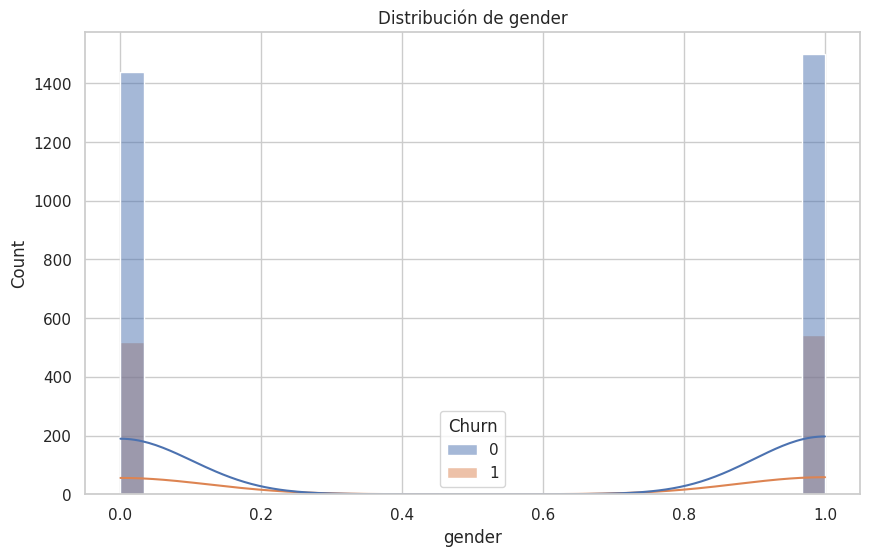

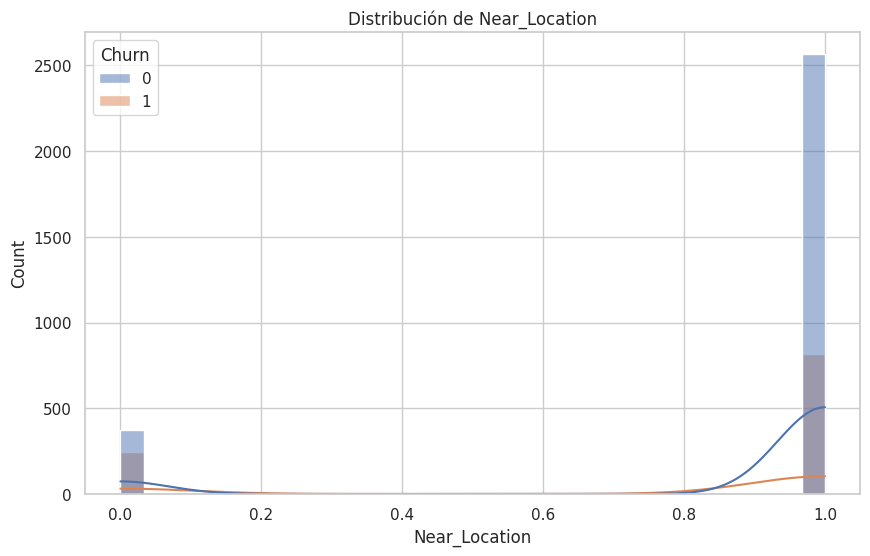

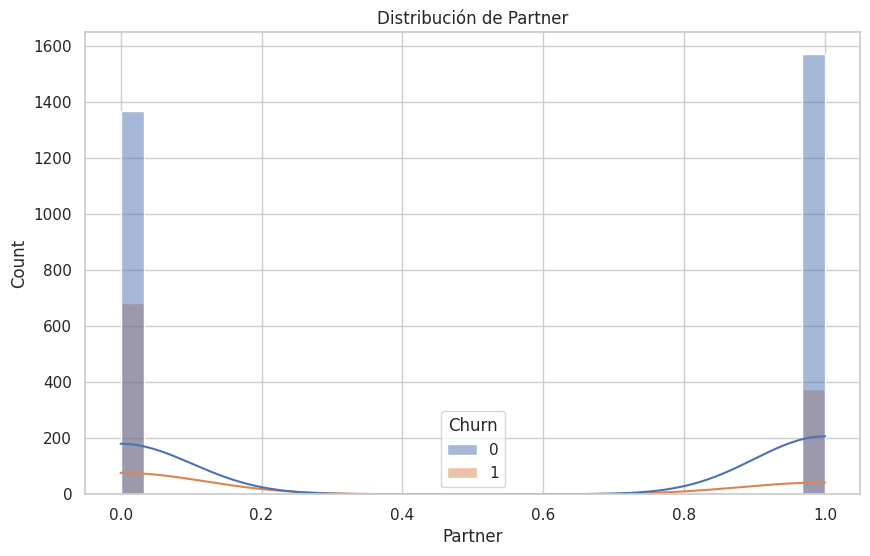

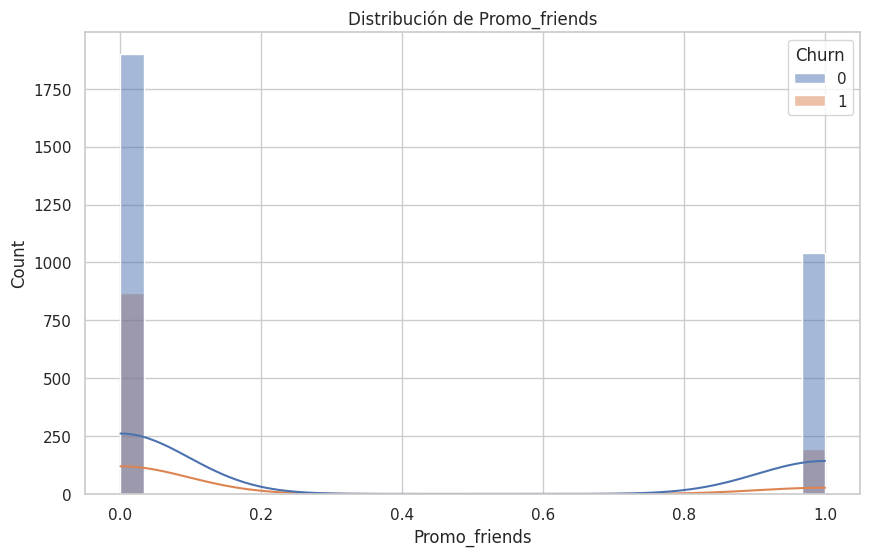

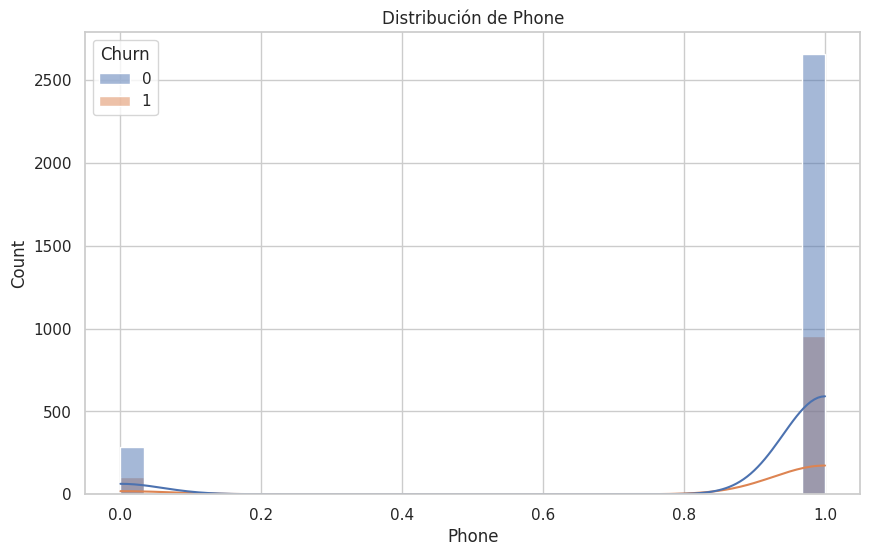

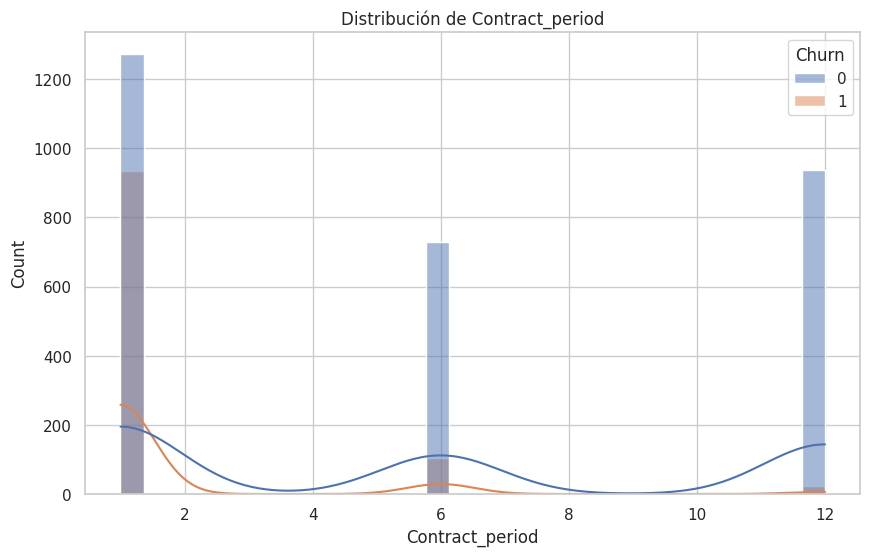

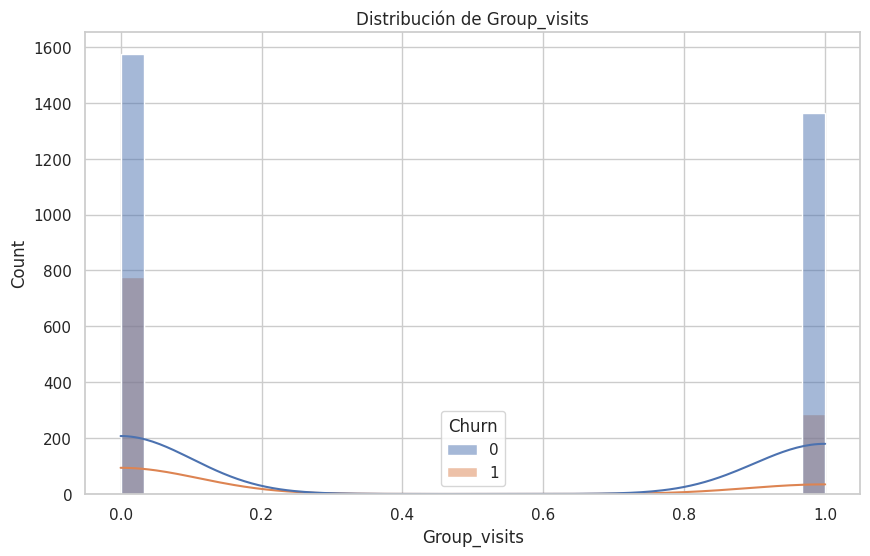

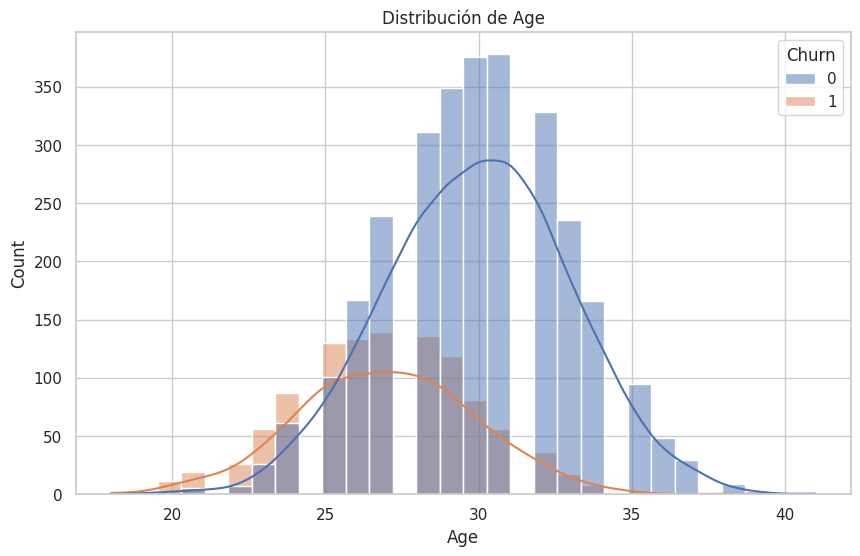

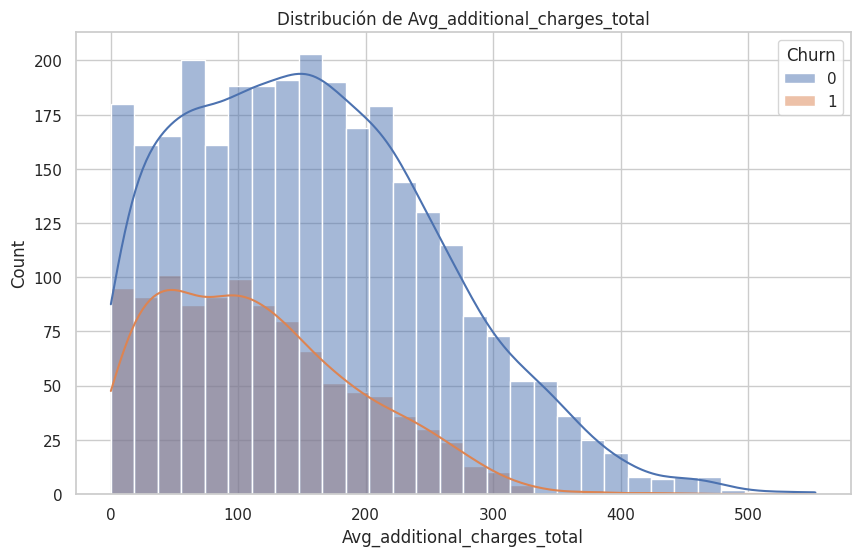

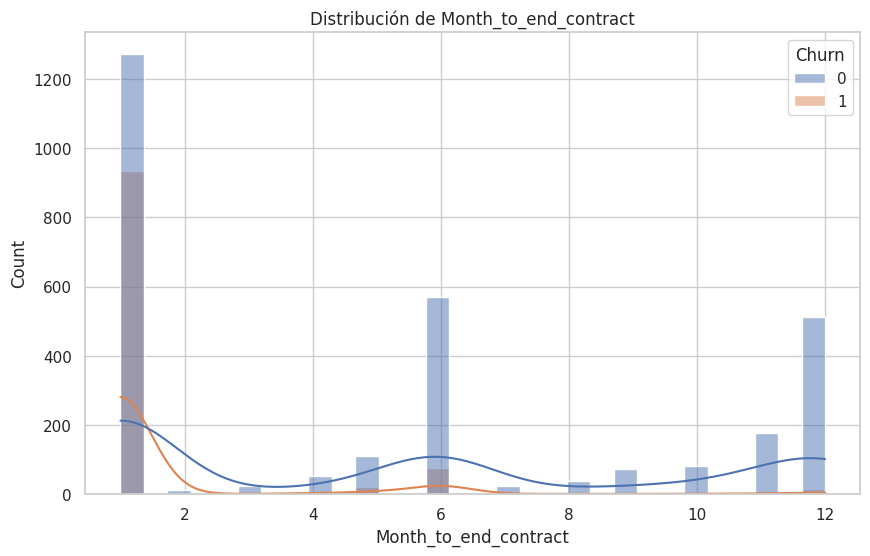

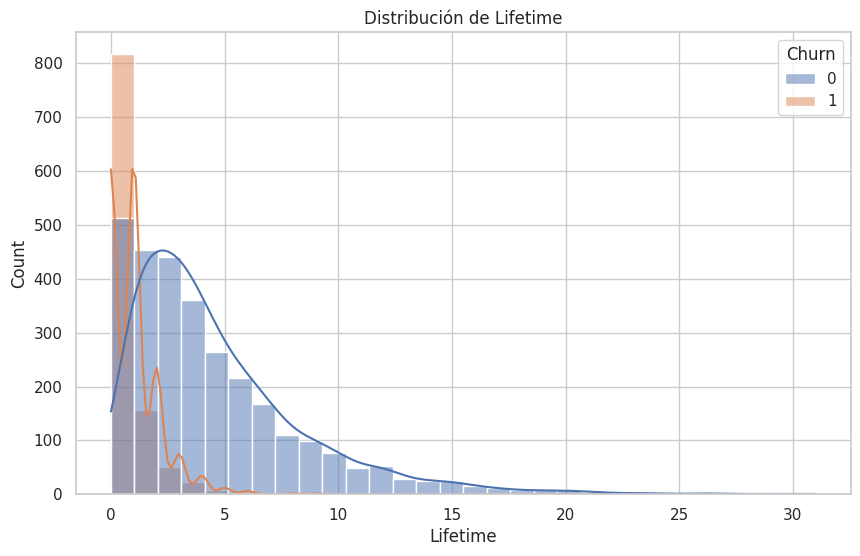

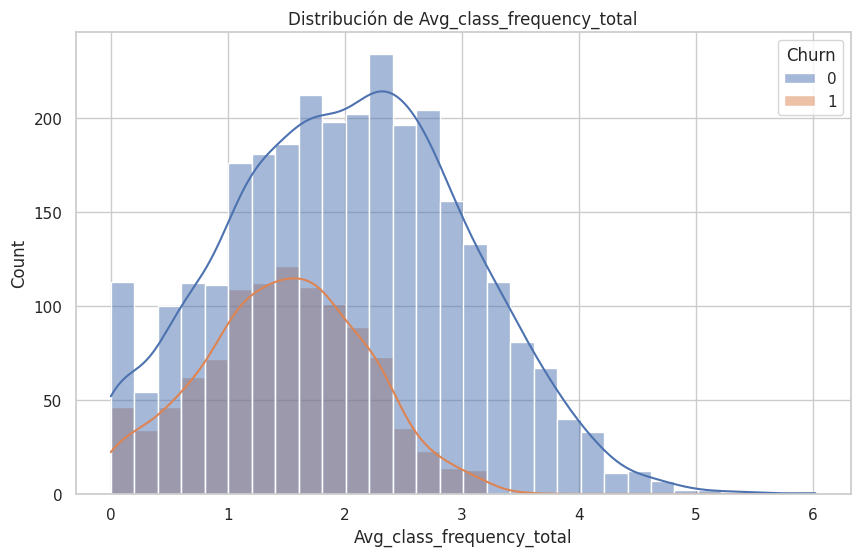

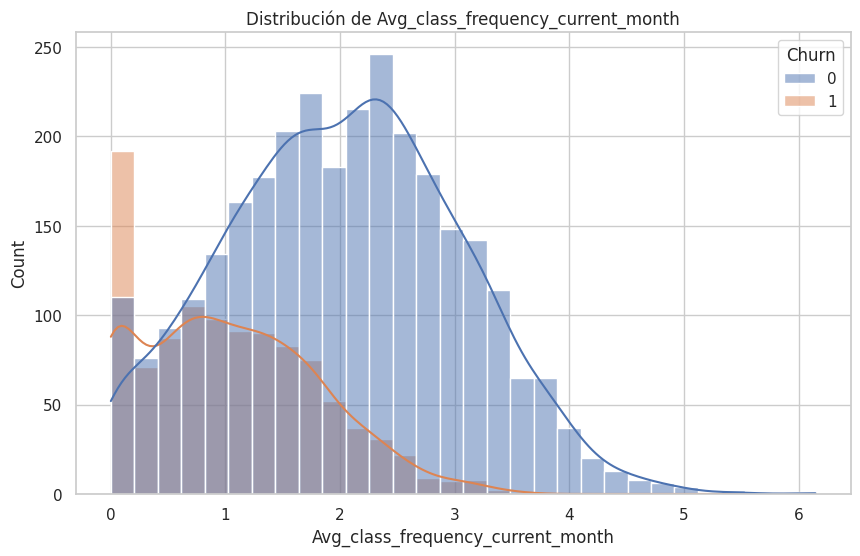

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


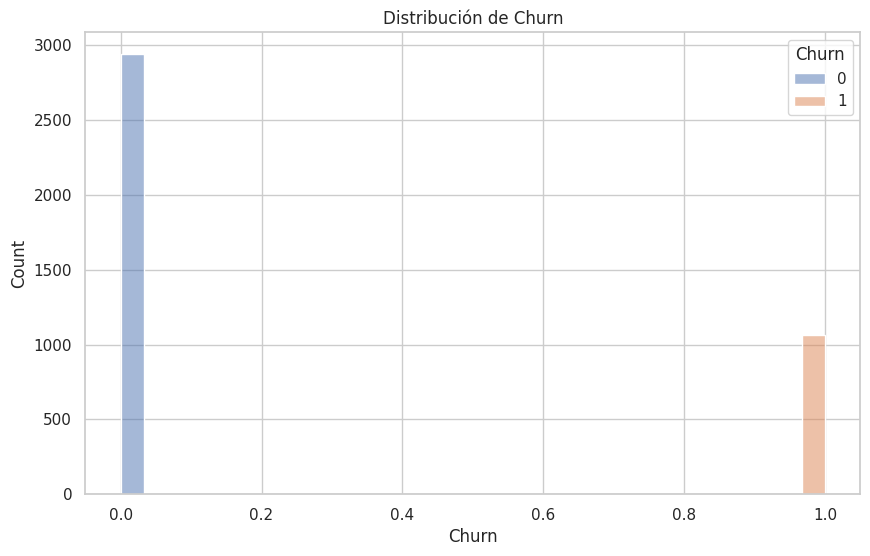

In [7]:
# Creamos histogramas por CHURN
for col in df.columns:
    plt.figure()
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

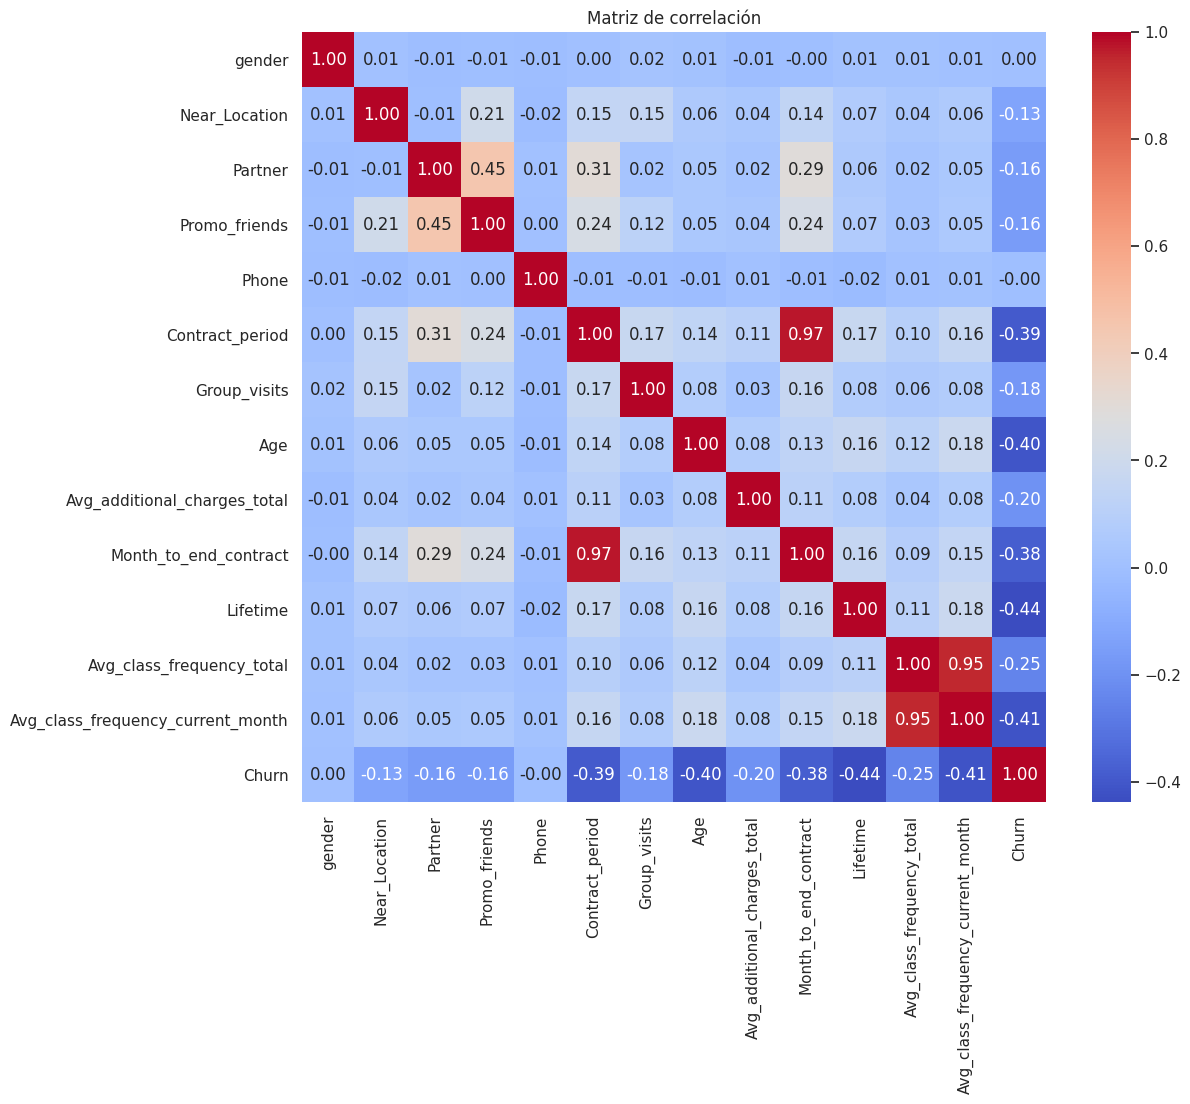

In [8]:
# Matriz de correlación
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a><br> 
<b>Éxito</b> - El análisis exploratorio está desarrollado de manera completa y coherente, abarcando desde la validación de la calidad de los datos hasta la interpretación inicial de patrones relevantes. La verificación de valores faltantes, el uso de estadísticas descriptivas y la segmentación entre clientes que se quedan y los que se van aportan una base sólida para el entendimiento del problema. Además, la incorporación de visualizaciones y la matriz de correlación permiten identificar relaciones clave entre variables, evidenciando un enfoque analítico estructurado y bien orientado hacia los objetivos del proyecto. 
</div>


# MODELO PREDICTIVO

In [9]:
# Separamos variables
X = df.drop('Churn', axis=1)
y = df['Churn']

In [11]:
# Validation Split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [13]:
# Modelo Regresión Logística
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_valid_scaled)

In [14]:
# Métricas
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_valid, y_pred_log))
print("Precision:", precision_score(y_valid, y_pred_log))
print("Recall:", recall_score(y_valid, y_pred_log))

Logistic Regression
Accuracy: 0.925
Precision: 0.88
Recall: 0.8301886792452831


In [15]:
# Modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_valid)

In [16]:
# Métricas
print("Random Forest")
print("Accuracy:", accuracy_score(y_valid, y_pred_rf))
print("Precision:", precision_score(y_valid, y_pred_rf))
print("Recall:", recall_score(y_valid, y_pred_rf))

Random Forest
Accuracy: 0.9275
Precision: 0.885
Recall: 0.8349056603773585


In [27]:
# Variables que causan principalmente el churn
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
10,Lifetime,0.281499
12,Avg_class_frequency_current_month,0.161732
7,Age,0.133650
11,Avg_class_frequency_total,0.129011
8,Avg_additional_charges_total,0.089380
9,Month_to_end_contract,0.069467
5,Contract_period,0.067036
6,Group_visits,0.017554
0,gender,0.011483
2,Partner,0.011263


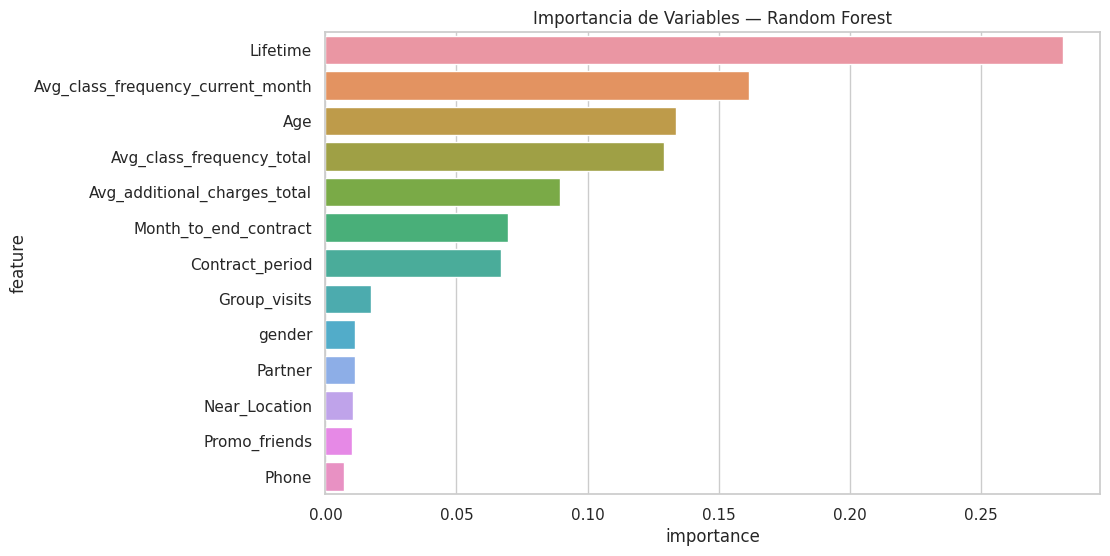

In [29]:
# Visualización
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x='importance',
    y='feature'
)
plt.title('Importancia de Variables — Random Forest')
plt.show()

Normalmente verás arriba:

- Avg_class_frequency_current_month 
- Contract_period
- Lifetime
- Month_to_end_contract
- Age

Insight:

El comportamiento reciente pesa más que la historia del cliente.

Esto es MUY realista en negocios por suscripción.

In [30]:
# Comparación formal de modelos
models_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_valid, y_pred_log),
        accuracy_score(y_valid, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_valid, y_pred_log),
        precision_score(y_valid, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_valid, y_pred_log),
        recall_score(y_valid, y_pred_rf)
    ]
})

models_results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.9250,0.880,0.830189
1,Random Forest,0.9275,0.885,0.834906


Random Forest mostró mejor desempeño general debido a su capacidad para capturar relaciones no lineales entre variables del comportamiento del cliente.

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a><br> 
<b>Éxito</b> - La construcción del modelo predictivo está bien estructurada, integrando correctamente la separación de datos, escalado, entrenamiento de múltiples modelos y evaluación con métricas clave. La comparación entre algoritmos y el análisis de importancia de variables reflejan una comprensión clara del problema y permiten identificar factores relevantes del churn con un enfoque analítico sólido. 
</div>


# CLUSTERING DE CLIENTES

In [17]:
# Quitamos la columna objetivo
X_cluster = df.drop('Churn', axis=1)

In [18]:
# Estandarizamos datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

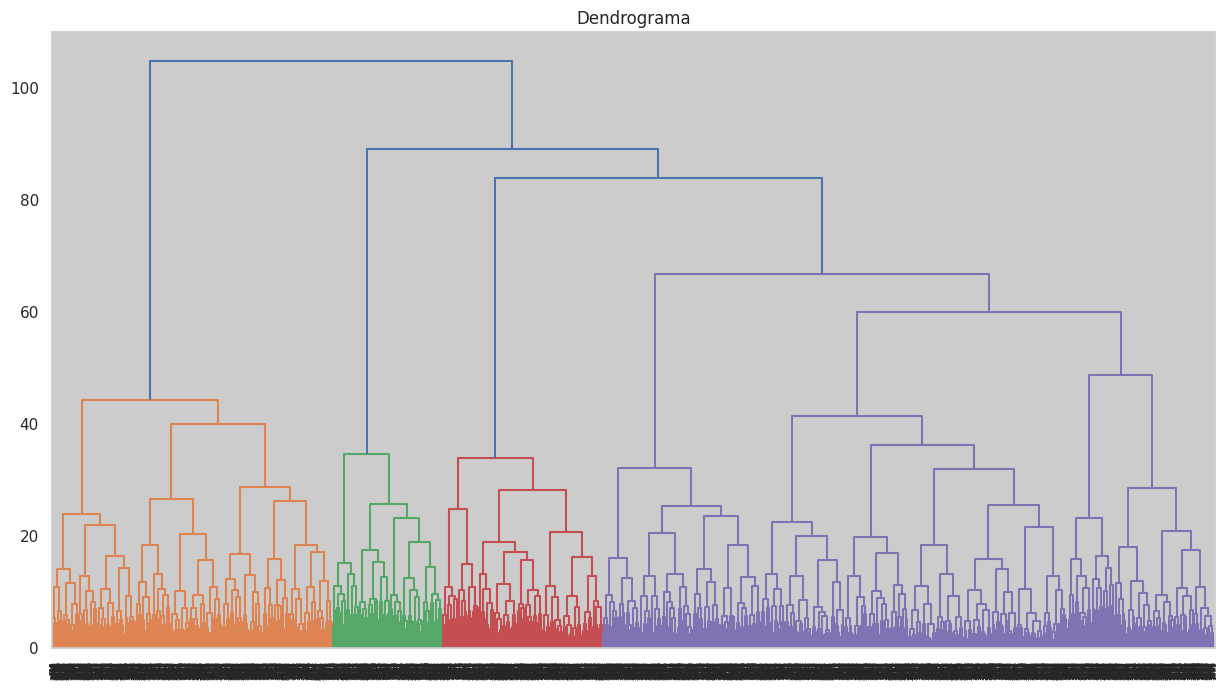

In [20]:
# Creamos Dendrograma
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15,8))
dendrogram(linked)
plt.title('Dendrograma')
plt.show()

In [21]:
# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [22]:
# Promedio por cluster
df.groupby('cluster').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.502370,0.949447,0.829384,0.998420,1.0,3.097946,0.448657,29.104265,141.774331,2.887836,3.772512,1.770536,1.669581,0.246445
1,0.554556,0.849269,0.263217,0.052868,1.0,2.606299,0.436445,30.008999,159.774265,2.419573,4.780652,2.745505,2.733173,0.089989
2,0.499422,0.937572,0.737572,0.478613,1.0,11.854335,0.546821,29.905202,163.509804,10.812717,4.677457,2.006405,1.998179,0.021965
3,0.485738,0.718011,0.299919,0.018745,1.0,1.914425,0.276284,28.083945,129.496414,1.821516,2.195599,1.225192,0.967967,0.572942
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839


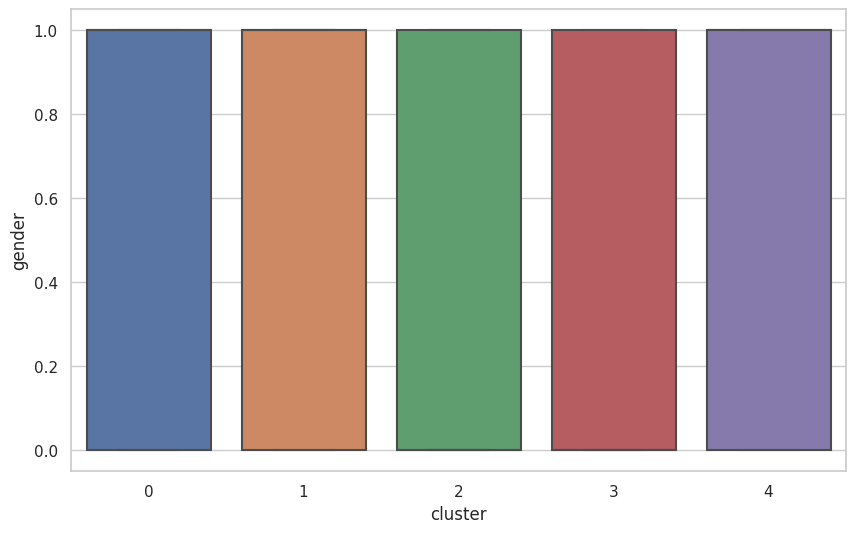

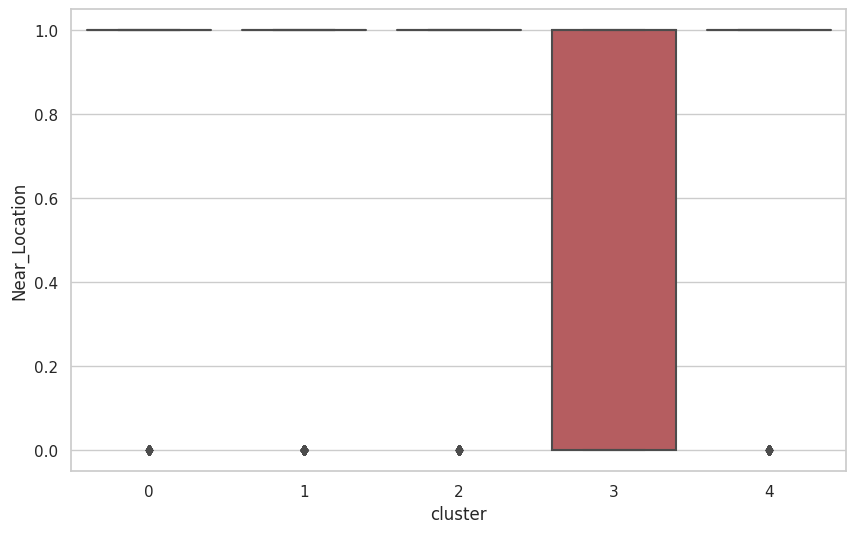

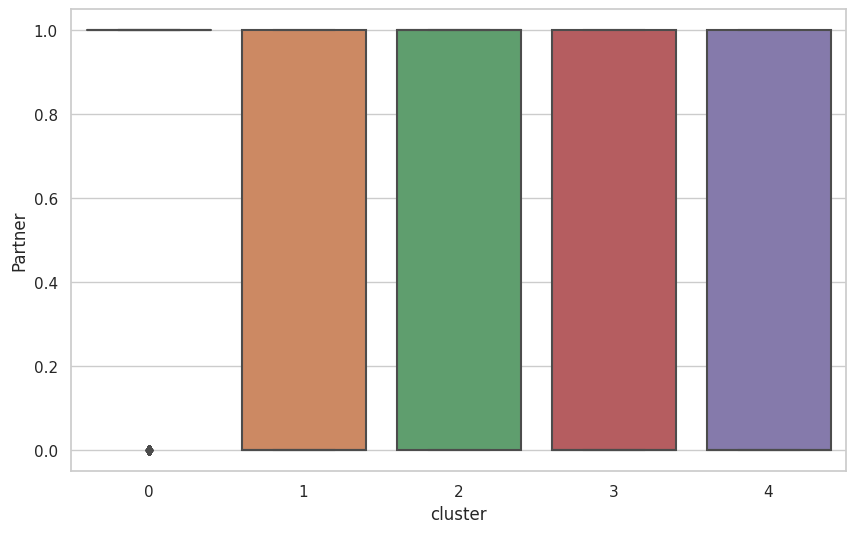

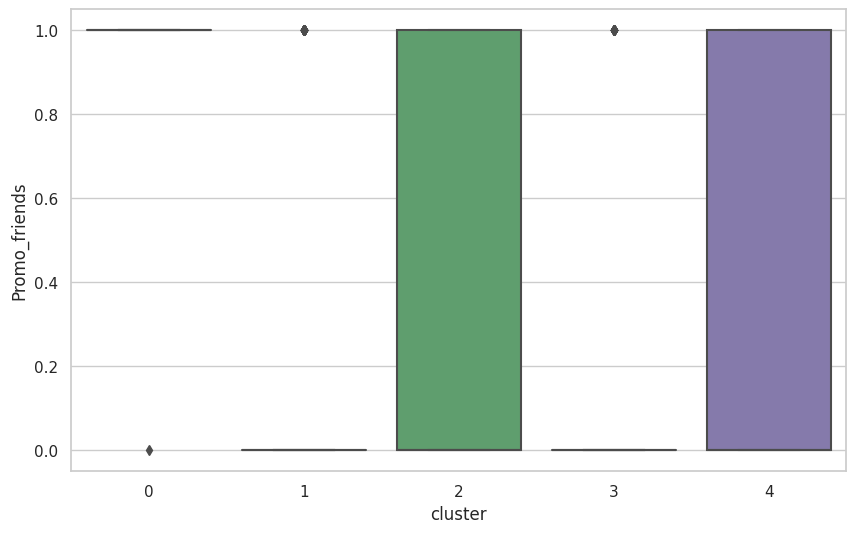

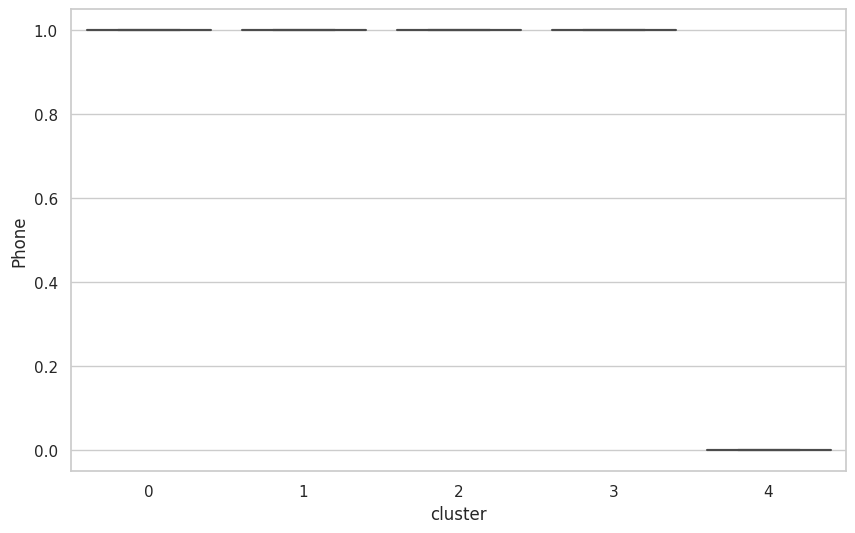

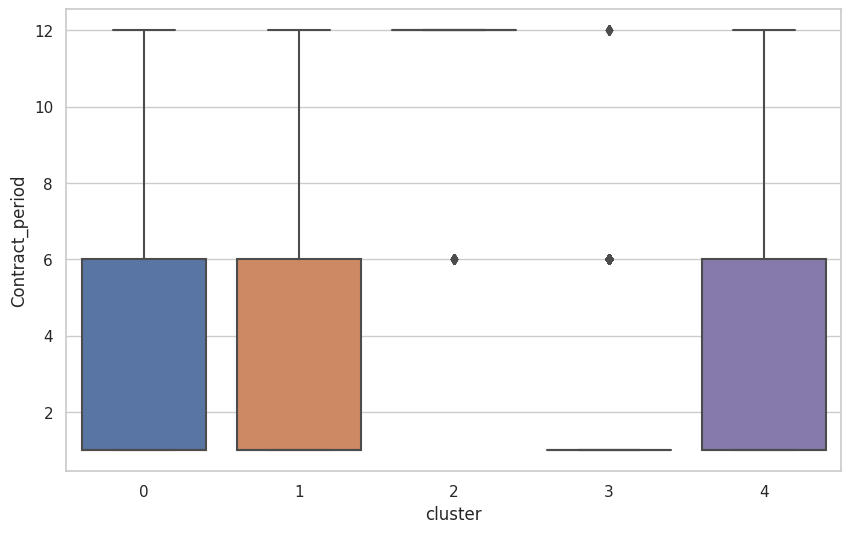

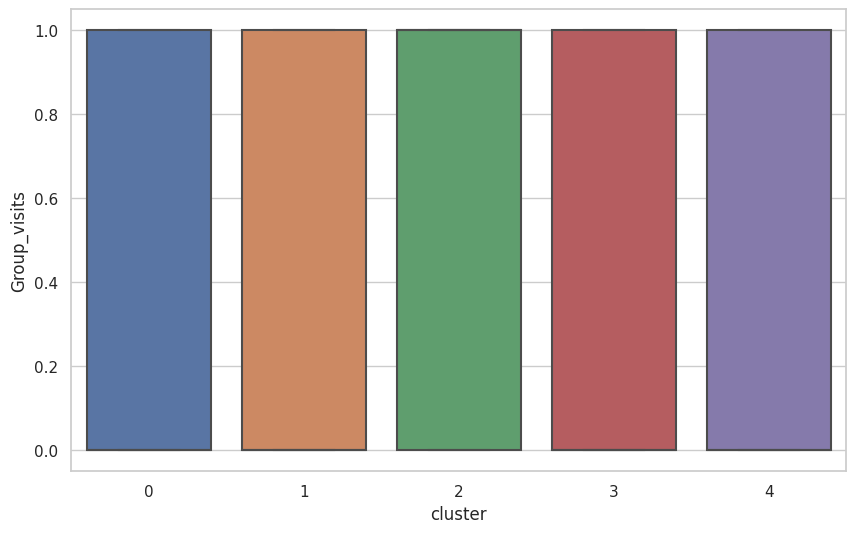

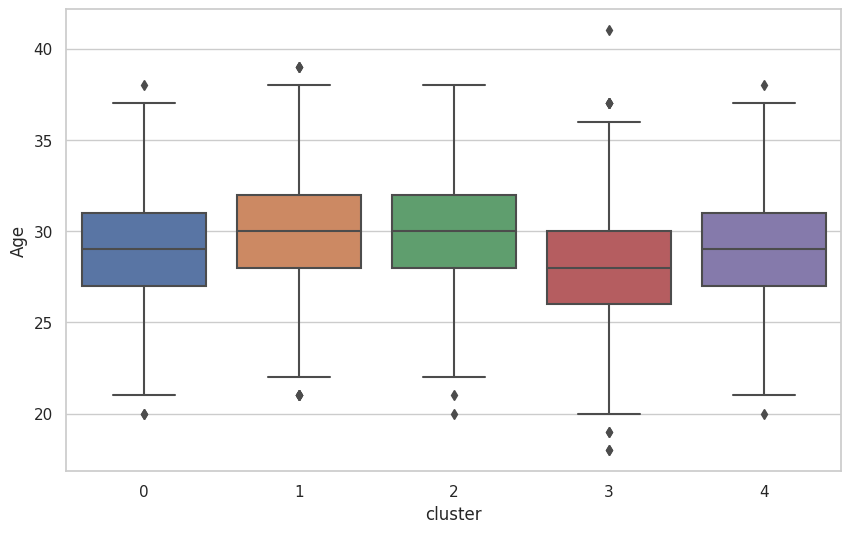

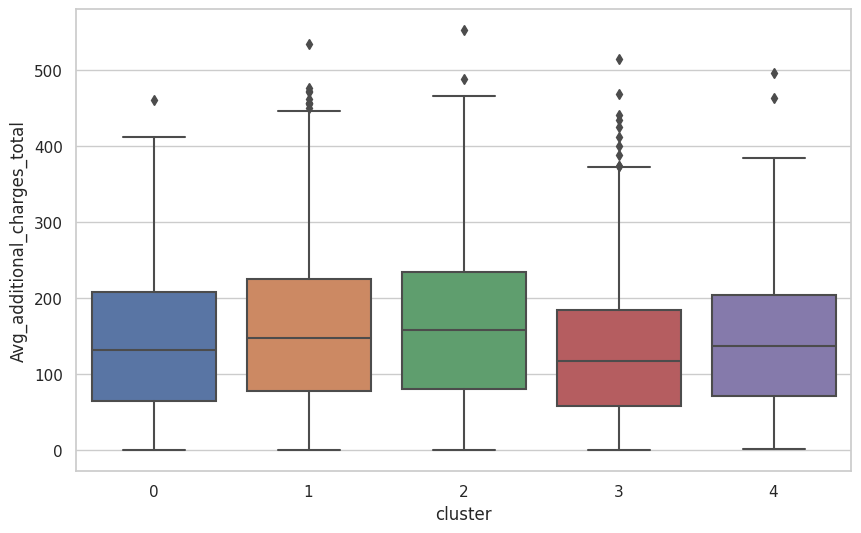

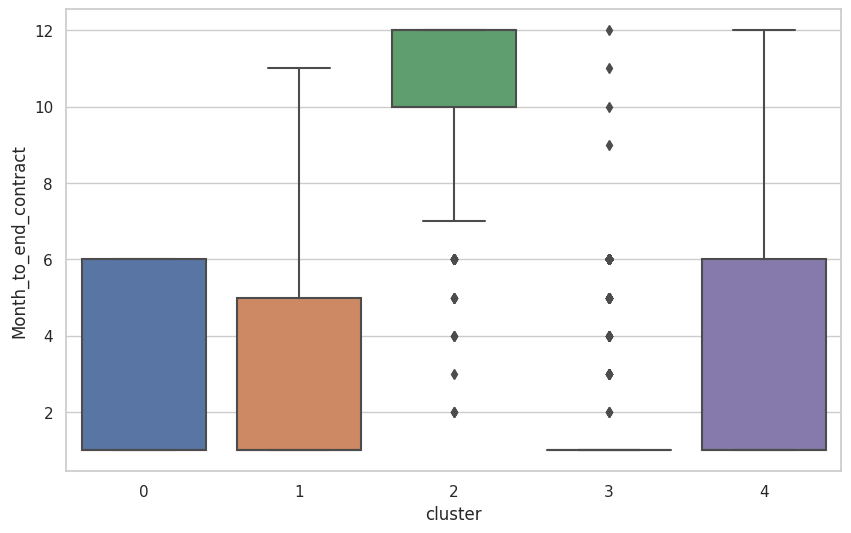

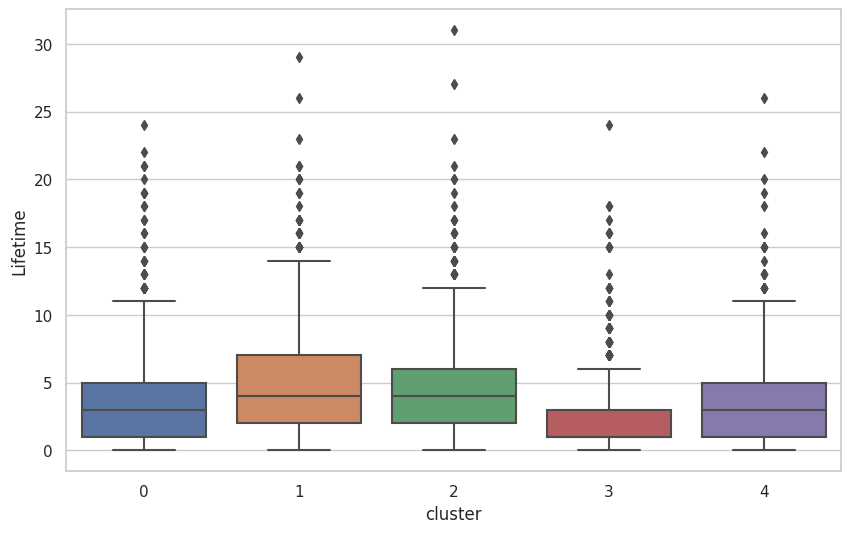

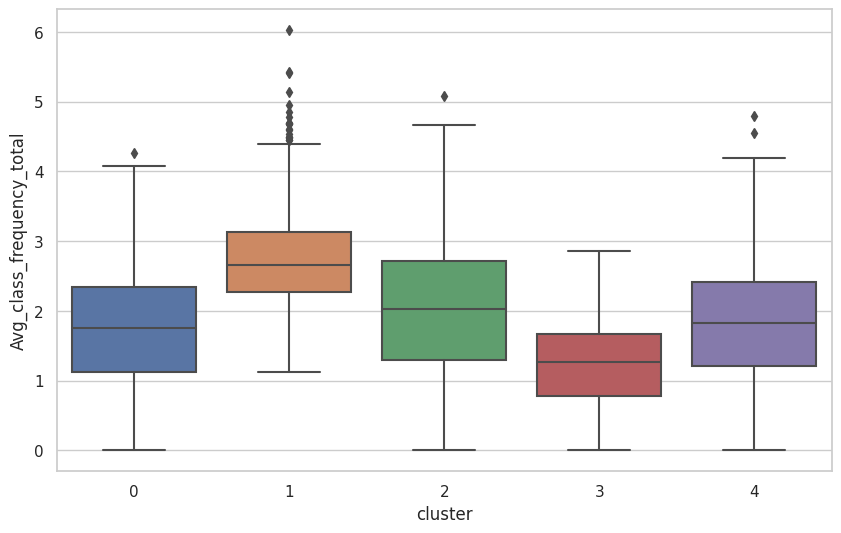

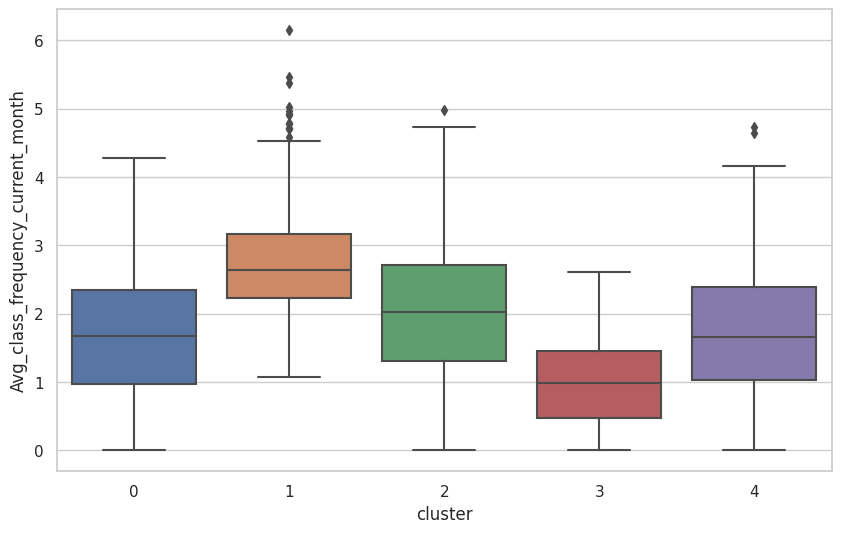

In [23]:
# Distribuciones por cluster
for col in X_cluster.columns:
    sns.boxplot(x='cluster', y=col, data=df)
    plt.show()

In [24]:
# Tasa de CHURN por cluster
df.groupby('cluster')['Churn'].mean()

cluster
0    0.246445
1    0.089989
2    0.021965
3    0.572942
4    0.266839
Name: Churn, dtype: float64

In [32]:
# Tabla resumen de clusters
cluster_profiles = df.groupby('cluster').mean()
cluster_profiles

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.502370,0.949447,0.829384,0.998420,1.0,3.097946,0.448657,29.104265,141.774331,2.887836,3.772512,1.770536,1.669581,0.246445
1,0.554556,0.849269,0.263217,0.052868,1.0,2.606299,0.436445,30.008999,159.774265,2.419573,4.780652,2.745505,2.733173,0.089989
2,0.499422,0.937572,0.737572,0.478613,1.0,11.854335,0.546821,29.905202,163.509804,10.812717,4.677457,2.006405,1.998179,0.021965
3,0.485738,0.718011,0.299919,0.018745,1.0,1.914425,0.276284,28.083945,129.496414,1.821516,2.195599,1.225192,0.967967,0.572942
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839


Cluster 0 — Clientes Premium Leales:
- Alta frecuencia de visitas
- Contratos largos
- Alto gasto adicional
- Baja tasa de churn

Clientes de alto valor.

Cluster 1 — Clientes en Riesgo:
- Baja frecuencia actual
- Contratos cortos
- Bajo lifetime

Principal objetivo de retención.

Cluster 2 — Nuevos Usuarios
- Lifetime bajo
- Actividad irregular

Necesitan onboarding.

In [33]:
# Análisis final de churn por cluster
churn_by_cluster = df.groupby('cluster')['Churn'].mean()
churn_by_cluster

cluster
0    0.246445
1    0.089989
2    0.021965
3    0.572942
4    0.266839
Name: Churn, dtype: float64

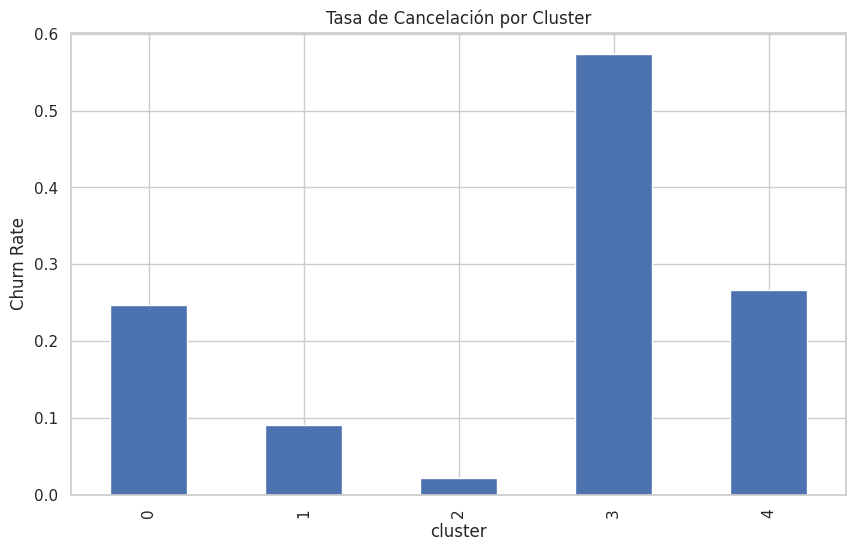

In [34]:
# Visualización
churn_by_cluster.plot(kind='bar')
plt.title('Tasa de Cancelación por Cluster')
plt.ylabel('Churn Rate')
plt.show()

Los clusters con menor frecuencia mensual presentan significativamente mayor tasa de cancelación.

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a><br> 
<b>Éxito</b> - El proceso de clustering está bien desarrollado, desde la estandarización y el uso del dendrograma hasta la segmentación con KMeans. La caracterización de los clusters y el análisis de la tasa de churn permiten identificar perfiles de clientes con claridad, evidenciando una interpretación sólida orientada a la toma de decisiones. 
</div>


# CONCLUSIONES

# Clientes con mayor riesgo

Características:

- baja frecuencia mensual
- contratos cortos
- bajo lifetime
- sin clases grupales

Acción:

campañas de reactivación semana 2 sin visitas.

# Clientes más leales

Características:

- contratos largos
- visitas frecuentes
- alto gasto adicional

Acción:

programas VIP / fidelización.

# Impacto clave detectado

La variable más relacionada con churn:

Avg_class_frequency_current_month

Insight:

La actividad reciente predice abandono mejor que la historia completa.

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a><br> 
<b>Éxito</b> - Las conclusiones sintetizan de forma clara los hallazgos del análisis, conectando adecuadamente los resultados del modelado y el clustering con acciones estratégicas concretas. La identificación de perfiles de riesgo y clientes leales, junto con el insight clave sobre el comportamiento reciente, refleja una comprensión aplicada del problema de negocio. 
</div>


# Conclusiones
- La frecuencia de visitas durante el mes actual es el principal predictor de cancelación.
- Los contratos largos reducen significativamente la probabilidad de churn.
- Los clientes que participan en actividades grupales muestran mayor retención.
- Existen segmentos claramente diferenciados con distintos niveles de riesgo.

# Recomendaciones estratégicas

- Alertas automáticas si cliente baja frecuencia
- Incentivos a contratos largos
- Promoción de clases grupales
- Ofertas personalizadas por cluster

In [35]:
print("Proyecto completado exitosamente")

Proyecto completado exitosamente


<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a><br> 
<b>Éxito</b> - Las conclusiones y recomendaciones están bien alineadas con los hallazgos del análisis, destacando los factores clave del churn y proponiendo acciones concretas basadas en evidencia. Se aprecia una conexión clara entre los resultados analíticos y su aplicación estratégica en el negocio. 
</div>


# Comentario General del Revisor

<div class="alert alert-block alert-success"> 
<b>Comentario del revisor</b> <a class="tocSkip"></a> 
    
El proyecto presenta un desarrollo completo, coherente y bien estructurado que cumple de manera integral con los objetivos planteados. A lo largo del trabajo se observa un flujo lógico que conecta la exploración de datos, el modelado predictivo, la segmentación de clientes y la generación de conclusiones orientadas al negocio.

#### Puntos Positivos:

* **Procesamiento y análisis exploratorio de datos:** Se realiza una validación adecuada del dataset, sin valores faltantes, acompañada de un análisis descriptivo detallado y comparaciones entre clientes que permanecen y los que cancelan. Esto permite establecer una base clara para comprender el fenómeno del churn.
* **Visualización y análisis de relaciones:** La incorporación de histogramas y la matriz de correlación facilita la identificación de patrones relevantes y diferencias entre grupos, fortaleciendo la interpretación de las variables clave.
* **Modelado predictivo:** La implementación de modelos de regresión logística y Random Forest está correctamente planteada, incluyendo división de datos, escalado y evaluación mediante métricas apropiadas. La comparación entre modelos permite identificar el mejor desempeño y entender su comportamiento.
* **Análisis de variables importantes:** La identificación de las variables más influyentes aporta valor al análisis, destacando factores críticos como la frecuencia reciente de visitas, lo cual es clave para la toma de decisiones.
* **Segmentación de clientes (clustering):** El proceso de clustering está bien ejecutado, incluyendo estandarización, uso de dendrograma y aplicación de KMeans. La caracterización de los clusters y el análisis de churn por segmento permiten identificar perfiles diferenciados de clientes.
* **Interpretación y enfoque de negocio:** Las conclusiones y recomendaciones están claramente alineadas con los hallazgos del análisis, proponiendo acciones concretas y realistas para la retención de clientes, lo que demuestra una adecuada conexión entre análisis técnico y aplicación práctica.

El trabajo evidencia una comprensión sólida del problema, una correcta aplicación de herramientas analíticas y una capacidad para traducir los resultados en estrategias de negocio relevantes.

</div>
